In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Crop Yeild Data.csv")
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [3]:
print(df.columns)
df.info()

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield',
       'Avg_Temperature', 'Max_Temperature', 'Min_Temperature'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 n

In [4]:
df = df.drop(columns=['Production'])

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Crop', 'Season', 'State']:
    df[col] = le.fit_transform(df[col])

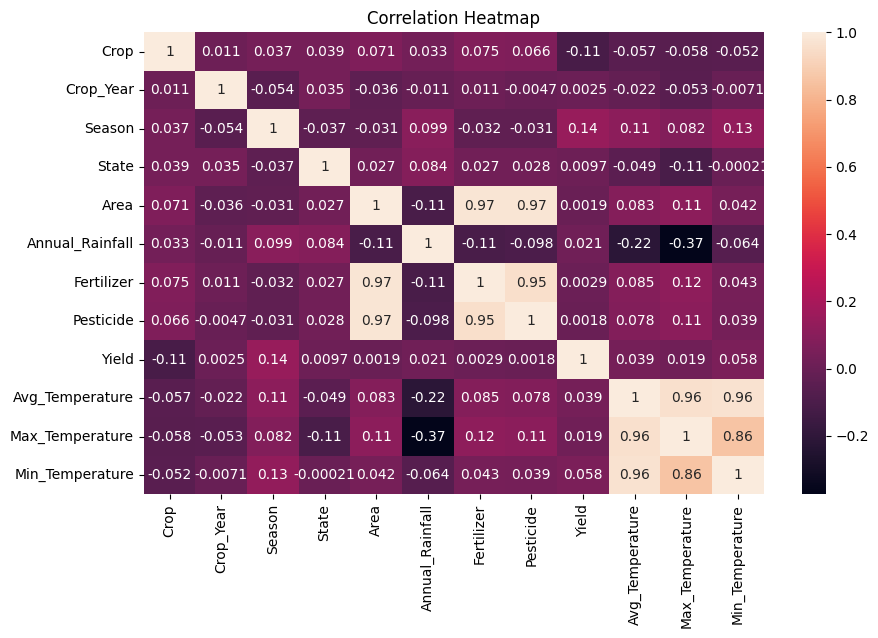

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

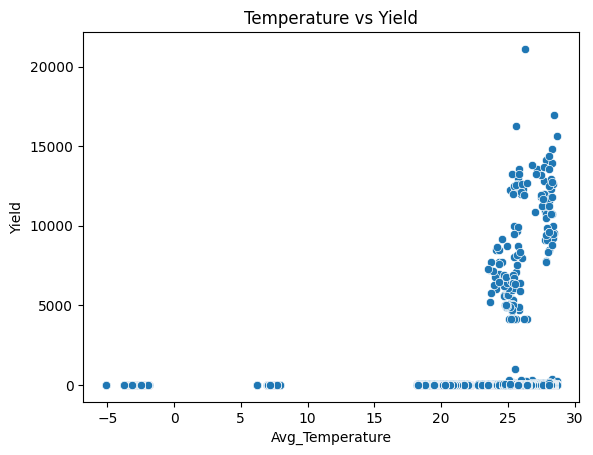

In [7]:
plt.figure()
sns.scatterplot(x=df['Avg_Temperature'], y=df['Yield'])
plt.title("Temperature vs Yield")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['Yield'])
y = df['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 18994.21304712795
R2 Score: 0.9762939736193733


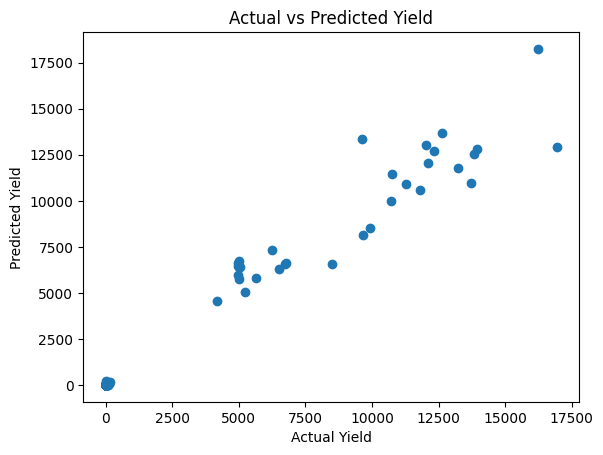

In [11]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

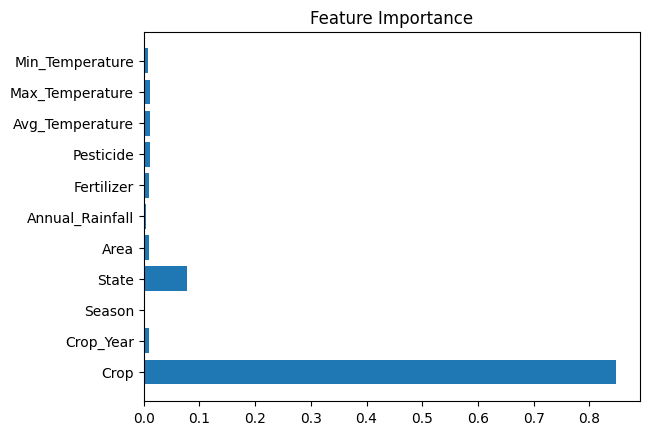

In [12]:
importances = model.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

In [14]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

# Random Forest (already trained)
rf_model = model

In [15]:
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

mse = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

# Create DataFrame
results = pd.DataFrame({
    'Model': models,
    'MSE': mse,
    'R2 Score': r2
})

print(results)

               Model            MSE  R2 Score
0  Linear Regression  772882.854355  0.035391
1      Decision Tree   55825.855818  0.930326
2      Random Forest   18994.213047  0.976294


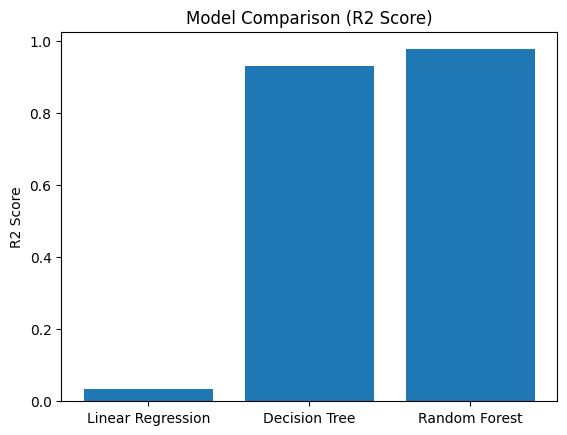

In [17]:
# R2 Score Comparison
plt.figure()
plt.bar(models, r2)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

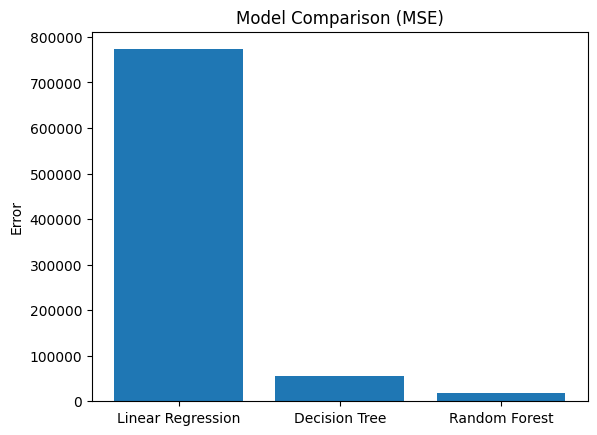

In [18]:
plt.figure()
plt.bar(models, mse)
plt.title("Model Comparison (MSE)")
plt.ylabel("Error")
plt.show()

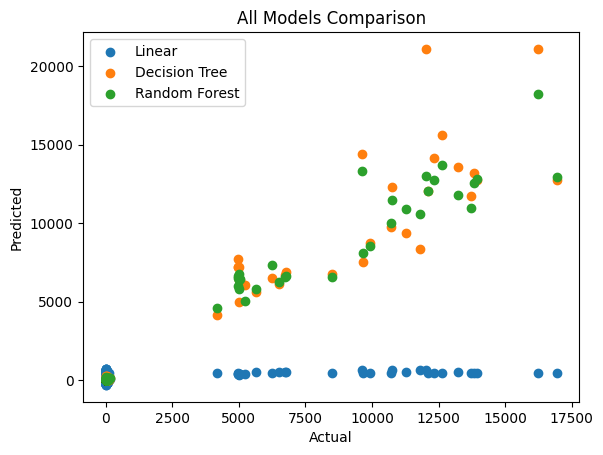

In [19]:
plt.figure()

plt.scatter(y_test, y_pred_lr, label="Linear")
plt.scatter(y_test, y_pred_dt, label="Decision Tree")
plt.scatter(y_test, y_pred_rf, label="Random Forest")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("All Models Comparison")
plt.show()